<a href="https://colab.research.google.com/github/argoubizakaria-web/SQL-VideoGame-Tournament-Analysis/blob/main/Argi%20avec%20Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler

In [18]:
Agri = pd.read_csv('/content/sample_data/crop_yield.csv')

In [19]:
Agri.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [20]:
Agri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [21]:
corr_matrix = Agri.corr(numeric_only=True)

In [22]:
Agri = Agri[Agri['Yield_tons_per_hectare'] >= 0]
Agri = Agri[Agri['Yield_tons_per_hectare'] <= 7]

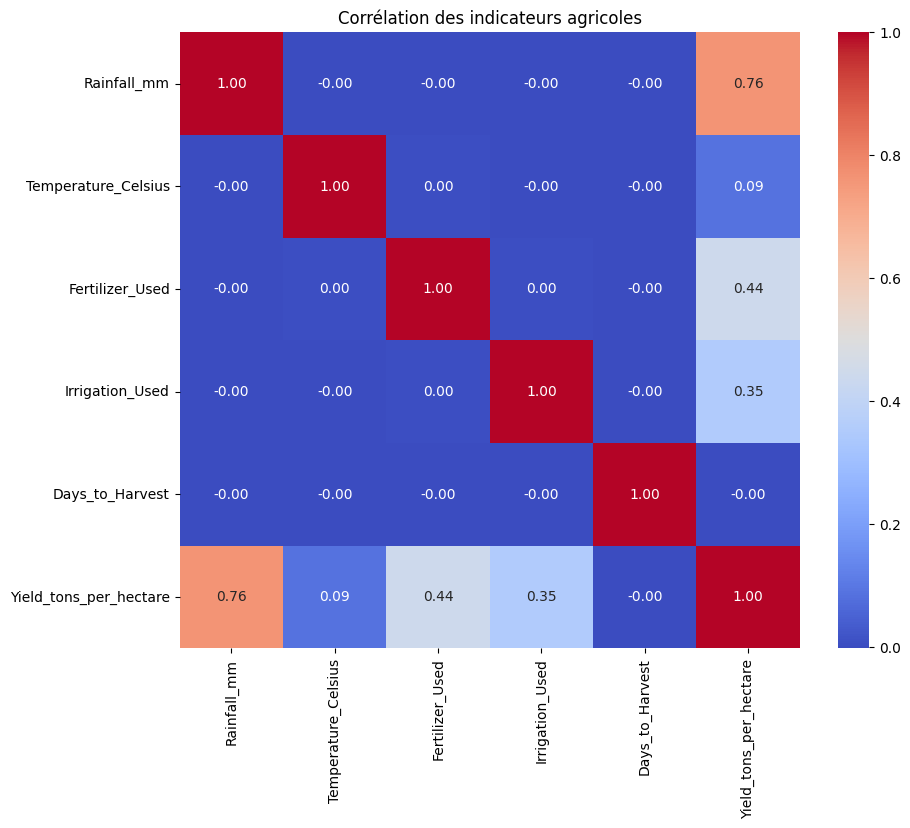

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélation des indicateurs agricoles')
plt.show()

In [26]:
# Nettoyage rapide : on transforme les textes (Fertilizer, Soil) en nombres
for col in Agri.columns:
    if Agri[col].dtype == 'object':
        Agri[col] = pd.factorize(Agri[col])[0]

print("Données chargées et converties en nombres !")

Données chargées et converties en nombres !


In [27]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

X = Agri.drop(columns=['Yield_tons_per_hectare'])
y = Agri['Yield_tons_per_hectare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
tree_model = DecisionTreeRegressor(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [29]:
score = tree_model.score(X_test, y_test)
print(f"Précision du modèle (R²) : {score:.4f}")

Précision du modèle (R²) : 0.8731


In [30]:
tree_boosted = DecisionTreeRegressor(
    max_depth=12,              # On creuse plus loin pour plus de précision
    min_samples_leaf=15,       # Chaque "feuille" doit avoir assez de données (évite le bruit)
    min_samples_split=40,      # On ne divise que si c'est statistiquement solide
    random_state=42
)

tree_boosted.fit(X_train, y_train)

print(f"Nouveau score Entraînement : {tree_boosted.score(X_train, y_train):.4f}")
print(f"Nouveau score Test : {tree_boosted.score(X_test, y_test):.4f}")

Nouveau score Entraînement : 0.8951
Nouveau score Test : 0.8891


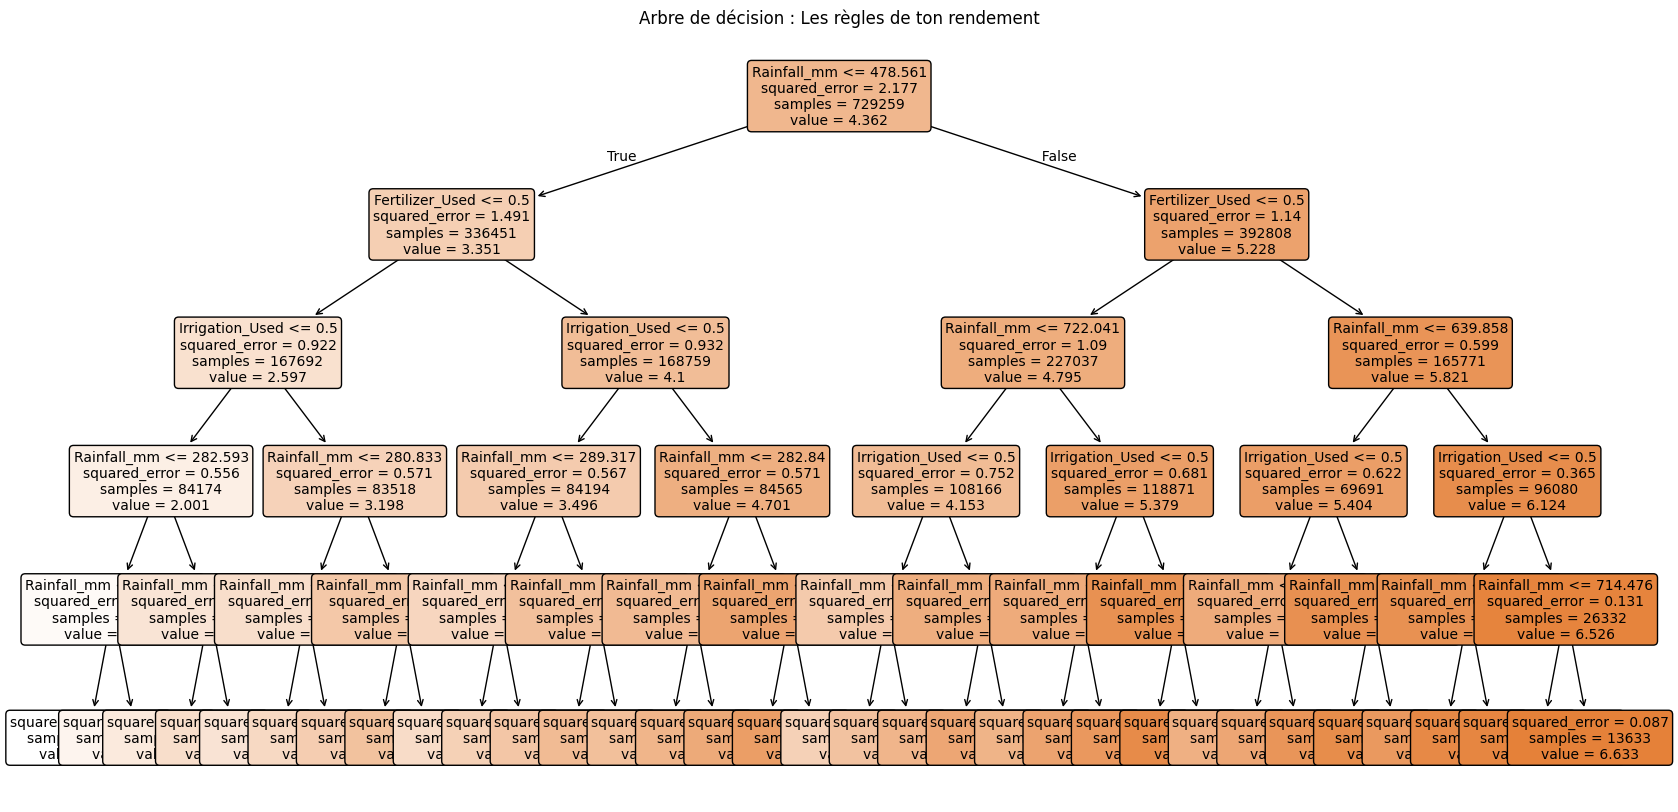

In [31]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Arbre de décision : Les règles de ton rendement")
plt.show()

In [32]:
from sklearn.model_selection import GridSearchCV

parametres = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20]
}

grid = GridSearchCV(DecisionTreeRegressor(), parametres, cv=3)
grid.fit(X_train, y_train)

print(f"Meilleurs réglages : {grid.best_params_}")
print(f"Meilleur score possible : {grid.best_score_:.4f}")

Meilleurs réglages : {'max_depth': 10, 'min_samples_leaf': 20}
Meilleur score possible : 0.8903


In [33]:
# Le modèle final validé par ton GridSearch
final_tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

final_tree.fit(X_train, y_train)

print("Modèle final prêt pour les prédictions !")

Modèle final prêt pour les prédictions !


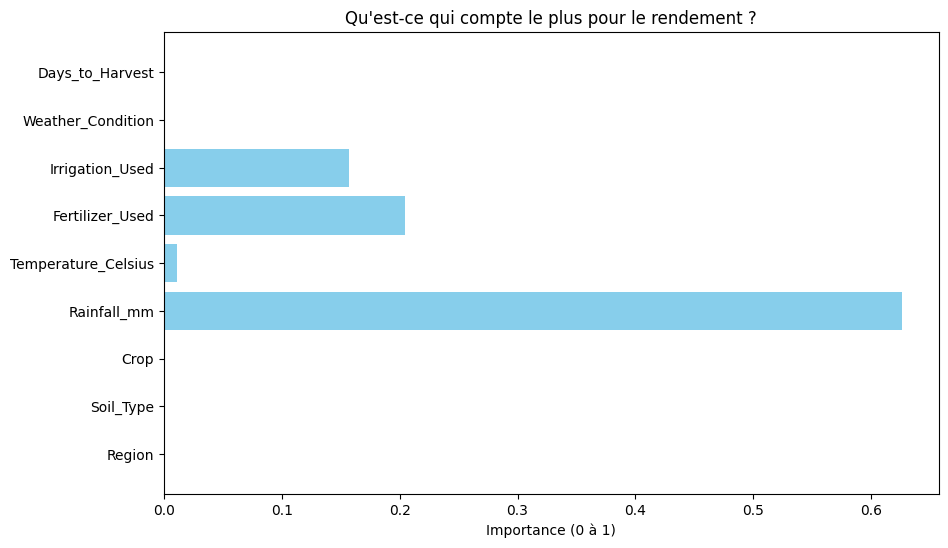

In [34]:
# On récupère l'importance des variables
importances = tree_boosted.feature_importances_
features = X.columns

# Création d'un petit graphique simple
plt.figure(figsize=(10,6))
plt.barh(features, importances, color='skyblue')
plt.title("Qu'est-ce qui compte le plus pour le rendement ?")
plt.xlabel("Importance (0 à 1)")
plt.show()

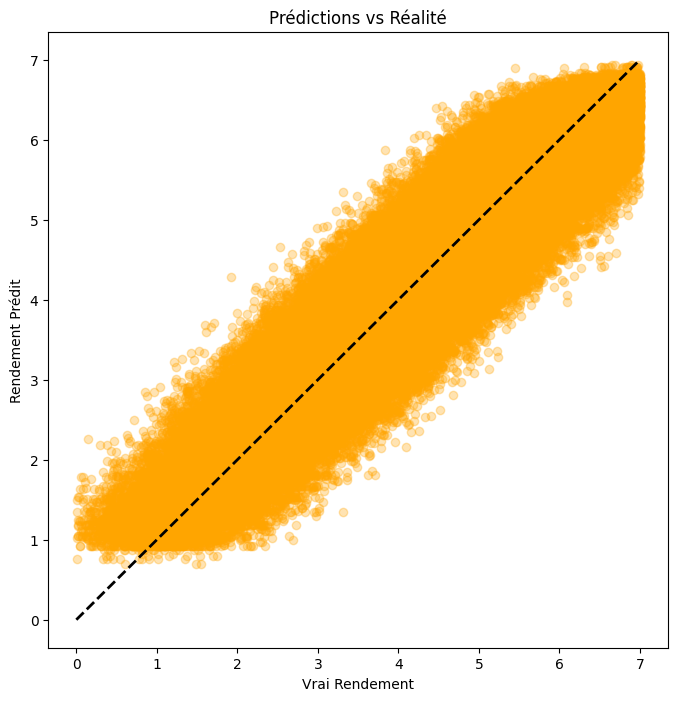

In [35]:
y_pred = tree_boosted.predict(X_test)

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.3, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Ligne de perfection
plt.xlabel("Vrai Rendement")
plt.ylabel("Rendement Prédit")
plt.title("Prédictions vs Réalité")
plt.show()

In [38]:
# On définit final_model en prenant le meilleur résultat du GridSearch
final_model = grid.best_estimator_

# Maintenant, ta ligne 19 fonctionnera :
rendement_final = final_model.predict(nouveau_df)

In [39]:
# 1. Simuler les données d'un nouveau champ
# Remplace les noms par ceux de tes colonnes exactes (ex: 'Rainfall_mm', etc.)
test_champ = {
    'Rainfall_mm': [500],
    'Temperature_Celsius': [25.5],
    'Fertilizer_Used': [1],
    'Soil_Type': [2],
    'Irrigation_Used': [1],
    'Days_to_Harvest': [120]
}

# 2. Créer le DataFrame
nouveau_df = pd.DataFrame(test_champ)

# 3. Aligner les colonnes (très important sur Colab pour éviter les erreurs)
nouveau_df = nouveau_df.reindex(columns=X_train.columns, fill_value=0)

# 4. Faire la prédiction
rendement_final = final_model.predict(nouveau_df)

print(f"✅ Prédiction Colab terminée !")
print(f"Le rendement estimé est de : {rendement_final[0]:.2f} t/ha")

✅ Prédiction Colab terminée !
Le rendement estimé est de : 5.76 t/ha
